# Bước 4: Huấn luyện mô hình Random Forest Classifier

Notebook này thực hiện huấn luyện mô hình **Random Forest Classifier** để dự đoán xếp hạng học lực (A-F) của sinh viên dựa trên tập dữ liệu đã được tiền xử lý.

## 1. Import thư viện

In [25]:
import os
import sys
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Imported necessary libraries successfully!")

Imported necessary libraries successfully!


## 2. Đọc dữ liệu và chuẩn bị đặc trưng

In [26]:
# Tìm đường dẫn tệp processed data bằng cách leo lên các thư mục cha
data_path = 'data/processed/Student_Performance_processed.csv'
for _ in range(5):
    if os.path.exists(data_path):
        break
    data_path = os.path.join('..', data_path)

df_encoded = pd.read_csv(data_path)

# Danh sách đặc trưng khách quan (23 features)
objective_features = [
    # Numerical features
    'age', 'study_hours', 'attendance_percentage',
    # Binary features
    'school_type', 'internet_access', 'extra_activities',
    # Ordinal feature
    'parent_education',
    # One-Hot Encoded features
    'gender_male', 'gender_female', 'gender_other',
    'travel_time_<15 min', 'travel_time_15-30 min', 'travel_time_30-60 min', 'travel_time_>60 min',
    'study_method_notes', 'study_method_textbook', 'study_method_group study', 
    'study_method_coaching', 'study_method_mixed', 'study_method_online videos'
]

# Tạo Interaction Features (đặc trưng tương tác)
df_encoded['study_hours_x_attendance'] = df_encoded['study_hours'] * df_encoded['attendance_percentage']
df_encoded['study_hours_squared'] = df_encoded['study_hours'] ** 2
df_encoded['attendance_squared'] = df_encoded['attendance_percentage'] ** 2

objective_features += ['study_hours_x_attendance', 'study_hours_squared', 'attendance_squared']

print(f"Loaded processed data: {df_encoded.shape[0]} rows, {df_encoded.shape[1]} columns.")
print(f"Feature count: {len(objective_features)}")

Loaded processed data: 25000 rows, 29 columns.
Feature count: 23


## 3. Huấn luyện mô hình phân lớp (Dự đoán nhóm học lực A-F)

Dự báo xếp hạng học lực đa lớp (`final_grade` gồm 6 mức: **A, B, C, D, E, F**) sử dụng các đặc trưng khách quan (không dùng điểm các môn học).

In [27]:
# Nhãn mục tiêu phân lớp
y = df_encoded['final_grade']
X = df_encoded[objective_features]

print("Target grade distribution (final_grade):")
print(y.value_counts().sort_index())

# Phân chia Train/Test set (có stratify để giữ phân bố lớp đồng đều)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain set: {X_train.shape[0]} rows, Test set: {X_test.shape[0]} rows")

Target grade distribution (final_grade):
final_grade
a    1205
b    2696
c    6161
d    6311
e    5672
f    2955
Name: count, dtype: int64

Train set: 20000 rows, Test set: 5000 rows


In [28]:
# Huấn luyện Random Forest Classifier với hyperparameters tối ưu (để tránh overfitting)
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=2,
    max_features='log2',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)
print("Training completed!")

Training completed!


## 4. Đánh giá mô hình

In [29]:
# Đánh giá trên Test set
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
target_labels = sorted(y.unique())

print(f"Accuracy: {acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_labels))

Accuracy: 79.18%

Classification Report:
              precision    recall  f1-score   support

           a       0.68      0.87      0.76       241
           b       0.71      0.71      0.71       539
           c       0.82      0.79      0.81      1232
           d       0.81      0.78      0.80      1262
           e       0.80      0.79      0.80      1135
           f       0.80      0.86      0.83       591

    accuracy                           0.79      5000
   macro avg       0.77      0.80      0.78      5000
weighted avg       0.79      0.79      0.79      5000



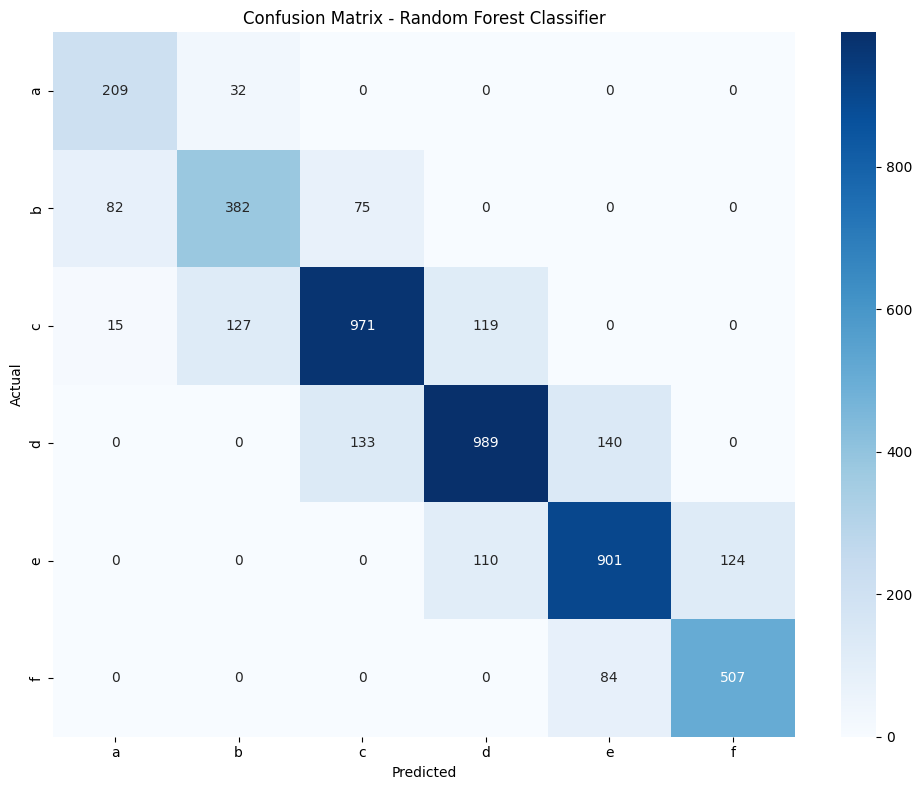

In [30]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=target_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_labels, yticklabels=target_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest Classifier')
plt.tight_layout()
plt.show()

Top 10 most important features:
  1. study_hours_x_attendance (0.2920)
  2. study_hours_squared (0.1858)
  3. study_hours (0.1801)
  4. attendance_percentage (0.0874)
  5. attendance_squared (0.0872)
  6. parent_education (0.0266)
  7. age (0.0266)
  8. extra_activities (0.0097)
  9. school_type (0.0094)
  10. travel_time_15-30 min (0.0076)


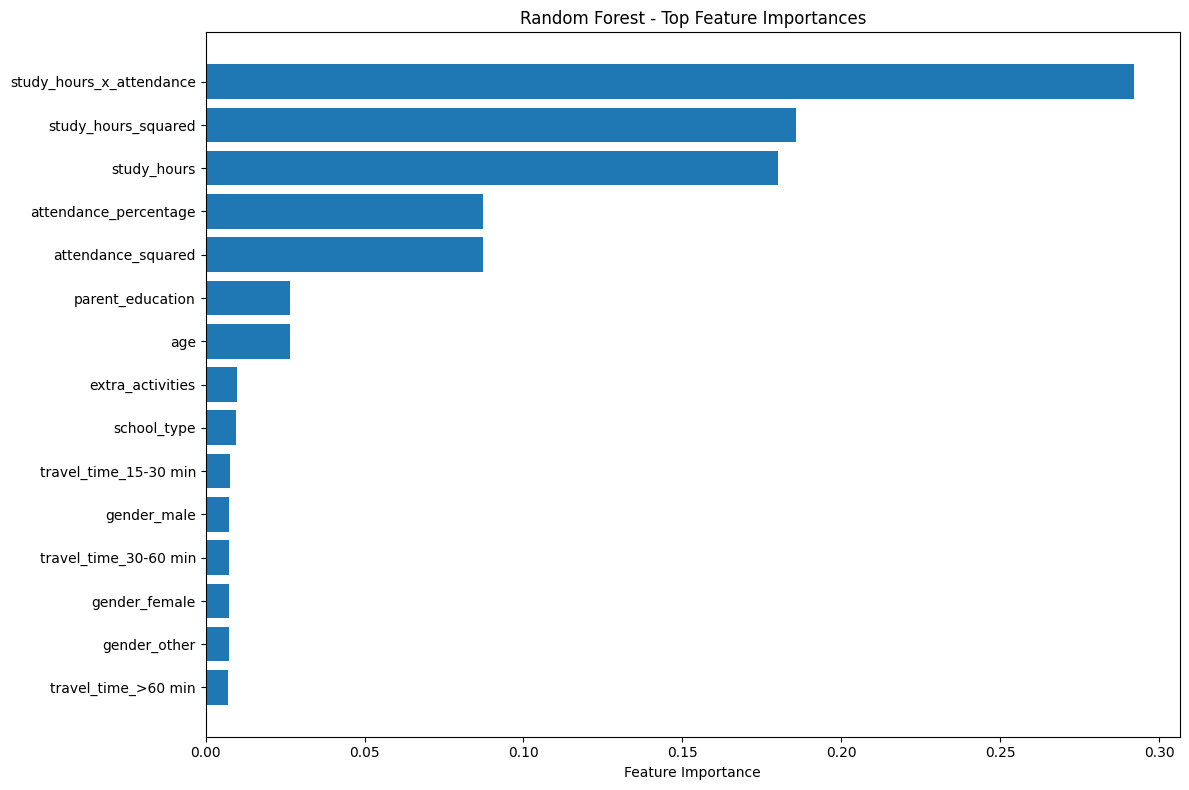

In [31]:
# Feature Importance
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

print("Top 10 most important features:")
for i in range(min(10, len(objective_features))):
    print(f"  {i+1}. {objective_features[indices[i]]} ({importances[indices[i]]:.4f})")

# Vẽ biểu đồ
plt.figure(figsize=(12, 8))
top_n = min(15, len(objective_features))
top_indices = indices[:top_n]
plt.barh(range(top_n), importances[top_indices], align='center')
plt.yticks(range(top_n), [objective_features[i] for i in top_indices])
plt.xlabel('Feature Importance')
plt.title('Random Forest - Top Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 5. Lưu mô hình

In [32]:
# Lưu mô hình vào thư mục models/ ở gốc dự án
project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
save_dir = os.path.join(project_root, 'models')
os.makedirs(save_dir, exist_ok=True)

model_path = os.path.join(save_dir, 'random_forest.pkl')
joblib.dump(model, model_path)
print(f"Model saved successfully to: {model_path}!")
print(f"Model uses {len(objective_features)} features.")

Model saved successfully to: d:\HK2_2026\DataMining\student-performance-mining-uth\models\random_forest.pkl!
Model uses 23 features.
